Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2053 images belonging to 6 classes.
Found 286 images belonging to 6 classes.
Found 291 images belonging to 6 classes.
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Phase 1: Training custom head (base frozen)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1160s 17s/step - accuracy: 0.3912 - loss: 6.2139 - val_accuracy: 0.7344 - val_loss: 5.9054
Epoch 2/10
 1/64 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - accuracy: 0.5625 - loss: 5.4285

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 479ms/step - accuracy: 0.5625 - loss: 5.4285 - val_accuracy: 0.7578 - val_loss: 5.8923
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 415ms/step - accuracy: 0.7790 - loss: 4.9664 - val_accuracy: 0.9102 - val_loss: 5.5707
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 1.0000 - loss: 4.4424 - val_accuracy: 0.9062 - val_loss: 5.5722
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 465ms/step - accuracy: 0.8754 - loss: 4.5990 - val_accuracy: 0.9219 - val_loss: 5.1929
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9688 - loss: 4.3086 - val_accuracy: 0.9531 - val_loss: 5.1935
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.9252 - loss: 4.3471 - val_accuracy: 0.9375 - val_loss: 4.8045
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9375 - loss: 4.1755 - val_accuracy: 0.9453 - val_loss: 4.7909
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 406ms/step - accuracy: 0.9536 - loss: 4.1404 - val_accuracy: 0.9492 - va

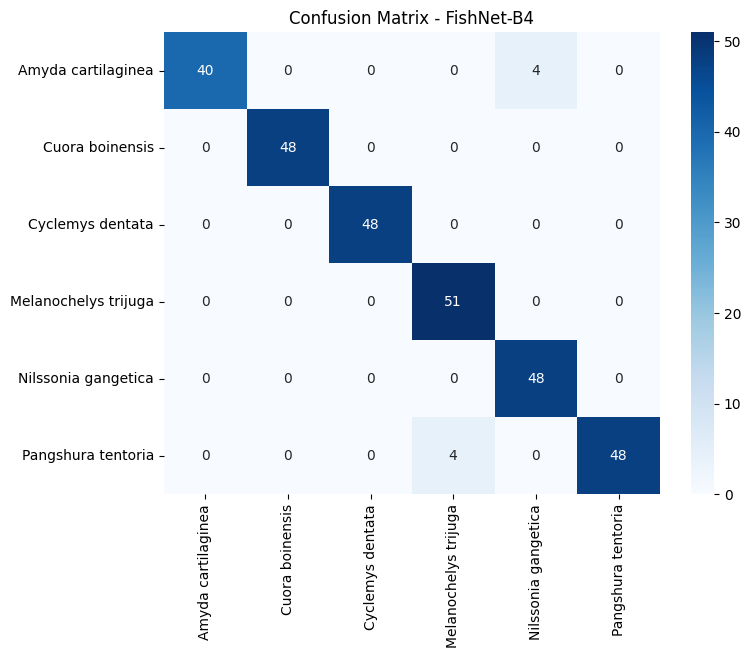

Model saved to Google Drive!


In [ ]:
# Install required packages (if not already installed)
!pip install -q tensorflow scikit-learn seaborn

# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Dataset paths
train_dir = '/content/drive/MyDrive/Dataset/Training'
validation_dir = '/content/drive/MyDrive/Dataset/Validation'
test_dir = '/content/drive/MyDrive/Dataset/Testing'
# Data generators
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# Load datasets
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Custom Squeeze-and-Excitation (SE) Block
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

# Load EfficientNetB4 (frozen initially)
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(380, 380, 3),
    pooling=None
)
base_model.trainable = False

# Build custom model
inputs = tf.keras.Input(shape=(380, 380, 3))
x = base_model(inputs, training=False)
x = se_block(x)  # Your custom SE block
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation='softmax')(x)

custom_model = models.Model(inputs, outputs, name="Turtle_Net-B4")

# Phase 1: Train only the custom head
custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training custom head (base frozen)")
history_phase1 = custom_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
    ]
)

# Phase 2: Fine-tune top layers of EfficientNetB4
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: Fine-tuning top layers")
history_phase2 = custom_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
    ]
)

# Evaluate
test_loss, test_acc = custom_model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Generate predictions
test_generator.reset()
y_pred = np.argmax(custom_model.predict(test_generator), axis=1)
y_true = test_generator.classes

# Trim predictions to match true labels (if needed)
y_pred = y_pred[:len(y_true)]

# Metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nPrecision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix - Turtle_Net-B4')
plt.show()

# Save model
custom_model.save("/content/drive/MyDrive/Turtle_Net-B4.h5")
print("Model saved to Google Drive!")

In [ ]:
# =======================
# 🐢 Grad-CAM for Turtle_Net-B4 (Local Images)
# =======================

# 1️⃣ Install dependencies
!pip install -q tensorflow scikit-learn seaborn matplotlib pillow

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from google.colab import files

# 2️⃣ Define SE Block
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

# 3️⃣ Build model again
def build_model(num_classes=6):
    base_model = tf.keras.applications.EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_shape=(380, 380, 3),
        pooling=None
    )
    x = base_model.output
    x = se_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

# Build and compile
model = build_model(num_classes=6)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("✅ Model rebuilt successfully")

# 4️⃣ Upload turtle images
print("📤 Upload your turtle test images (of 6 species)")
uploaded = files.upload()

# Create a folder to save Grad-CAM results
os.makedirs("gradcam_results", exist_ok=True)

# 5️⃣ Define Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap)
    return heatmap.numpy(), int(pred_index)

# Find the last conv layer automatically
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break
print(f"🔥 Last conv layer used for Grad-CAM: {last_conv_layer_name}")

# 6️⃣ Generate Grad-CAM for uploaded images
for filename in uploaded.keys():
    img_path = f"/content/{filename}"
    img = image.load_img(img_path, target_size=(380, 380))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    heatmap, pred_class = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Resize and overlay heatmap
    img = cv2.imread(img_path)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)

    # Save outputs
    base_name = os.path.splitext(filename)[0]
    original_path = f"gradcam_results/{base_name}_original.jpg"
    gradcam_path = f"gradcam_results/{base_name}_gradcam.jpg"

    cv2.imwrite(original_path, img)
    cv2.imwrite(gradcam_path, superimposed_img)
    print(f"✅ Saved: {gradcam_path}")

print("\n🎉 All Grad-CAMs generated and saved in 'gradcam_results/' folder!")

# 7️⃣ Zip and download results
!zip -r gradcam_results.zip gradcam_results
files.download("gradcam_results.zip")


✅ Model rebuilt successfully
📤 Upload your turtle test images (of 6 species)


Saving ambonesis.png to ambonesis.png
Saving Amyda1.jpeg to Amyda1.jpeg
Saving tentoria.jpeg to tentoria.jpeg
🔥 Last conv layer used for Grad-CAM: top_conv


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_484']]
Received: inputs=Tensor(shape=(1, 380, 380, 3))
  warnings.warn(msg)


✅ Saved: gradcam_results/ambonesis_gradcam.jpg
✅ Saved: gradcam_results/Amyda1_gradcam.jpg
✅ Saved: gradcam_results/tentoria_gradcam.jpg

🎉 All Grad-CAMs generated and saved in 'gradcam_results/' folder!
updating: gradcam_results/ (stored 0%)
updating: gradcam_results/pangshura tentoria_gradcam.jpg (deflated 2%)
updating: gradcam_results/Amyda_gradcam.jpg (deflated 2%)
updating: gradcam_results/nissonia gangetica_gradcam.jpg (deflated 3%)
updating: gradcam_results/pangshura tentoria_original.jpg (deflated 5%)
updating: gradcam_results/mela trijuga_original.jpg (deflated 3%)
updating: gradcam_results/Cuora ambones_gradcam.jpg (deflated 2%)
updating: gradcam_results/nissonia gangetica_original.jpg (deflated 7%)
updating: gradcam_results/cyclemis dentata_original.jpg (deflated 6%)
updating: gradcam_results/mela trijuga_gradcam.jpg (deflated 2%)
updating: gradcam_results/cyclemis dentata_gradcam.jpg (deflated 2%)
updating: gradcam_results/Cuora ambones_original.jpg (deflated 4%)
updating: 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Code for proving whether the SE clock is lightweight or not

# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models

# Define SE block
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, channels))(se)
    se = layers.Dense(channels // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(channels, activation='sigmoid', use_bias=False)(se)
    return layers.Multiply()([x, se])

# Load EfficientNetB4 backbone without top
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(380, 380, 3)
)

# Insert SE block after base model features
inputs = tf.keras.Input(shape=(380, 380, 3))
x = base_model(inputs, training=False)
x = se_block(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(6, activation='softmax')(x)
model_with_se = models.Model(inputs, outputs, name='EfficientNetB4_SE')

# Clone/define baseline EfficientNetB4 model without SE block
inputs2 = tf.keras.Input(shape=(380, 380, 3))
x2 = base_model(inputs2, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)
outputs2 = layers.Dense(6, activation='softmax')(x2)
model_without_se = models.Model(inputs2, outputs2, name='EfficientNetB4_baseline')

# Compile models (optional if only inference timing)
model_with_se.compile()
model_without_se.compile()

# Helper function for parameter counting and estimation of FLOPs can be done using tf.profiler or external tools

# For inference timing, run multiple iterations on input batch and average elapsed time

# Example timing code snippet:
import numpy as np
import time

dummy_input = np.random.rand(1, 380, 380, 3).astype(np.float32)

def inference_time(model, inputs, iterations=100):
    # Warmup
    for _ in range(10):
        model.predict(inputs)
    start = time.time()
    for _ in range(iterations):
        model.predict(inputs)
    end = time.time()
    avg_time = (end - start) / iterations
    return avg_time * 1000  # in milliseconds

time_with_se = inference_time(model_with_se, dummy_input)
time_without_se = inference_time(model_without_se, dummy_input)

print(f"Inference Time with SE block: {time_with_se:.2f} ms")
print(f"Inference Time without SE block: {time_without_se:.2f} ms")
print(f"Relative increase: {(time_with_se/time_without_se - 1)*100:.2f}%")

# For parameter count, you can use:
params_with_se = model_with_se.count_params()
params_without_se = model_without_se.count_params()
print(f"Params with SE block: {params_with_se}")
print(f"Params without SE block: {params_without_se}")
print(f"Parameter increase: {(params_with_se/params_without_se - 1)*100:.2f}%")

# FLOPs profiling generally requires additional profiling tools like tf.profiler, keras-flops, or third-party libraries


1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

In [ ]:
# === YOLOv8 Classification Model Performance Profiling (Fixed) ===
!pip install -q thop torch torchvision ultralytics

import torch
import time
import numpy as np
from ultralytics import YOLO
from thop import profile

# Load your trained or pretrained classifier
model = YOLO('yolov8n-cls.pt')  # Change to your trained weight if available

# Get the internal PyTorch model (needed for thop)
net = model.model

# --- 1️⃣ Parameter Count ---
params = sum(p.numel() for p in net.parameters()) / 1e6
print(f"Parameter count: {params:.2f} Million")

# --- 2️⃣ FLOPs (Using thop) ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dummy_input = torch.randn(1, 3, 224, 224).to(device)
net.to(device)

flops, params_thop = profile(net, inputs=(dummy_input,), verbose=False)
flops_g = flops / 1e9
print(f"FLOPs: {flops_g:.2f} G")

# --- 3️⃣ Average Inference Time (ms) ---
n_runs = 100
with torch.no_grad():
    # Warm-up
    for _ in range(10):
        _ = net(dummy_input)

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(n_runs):
        _ = net(dummy_input)
    torch.cuda.synchronize()
    end = time.time()

avg_inference_time_ms = ((end - start) / n_runs) * 1000
print(f"Average inference time per image: {avg_inference_time_ms:.2f} ms")

# --- 4️⃣ GPU Memory Usage ---
if torch.cuda.is_available():
    mem_mb = torch.cuda.memory_allocated() / (1024 ** 2)
    print(f"GPU Memory Used: {mem_mb:.2f} MB")
else:
    print("GPU not available.")

# --- Summary Table ---
print("\n--- YOLOv8 Classifier Performance Summary (224×224) ---")
print(f"Params (Millions): {params:.2f}")
print(f"FLOPs (G): {flops_g:.2f}")
print(f"Inference Time (ms): {avg_inference_time_ms:.2f}")
if torch.cuda.is_available():
    print(f"GPU Memory Use (MB): {mem_mb:.2f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Parameter count: 2.72 Million
FLOPs: 0.21 G
Average inference time per image: 3.02 ms
GPU Memory Used: 43.02 MB

--- YOLOv8 Classifier Performance Summary (224×224) ---
Params (Millions): 2.72
FLOPs (G): 0.21
Inference Time (ms): 3.02
GPU Memory Use (MB): 43.02


In [ ]:
# === Turtle_Net-B4 Model Performance Profiling (TF Profiler, No keras-flops) ===
!pip install -q tensorflow psutil

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np, time, psutil, os

# --- 1️⃣ Define SE (Squeeze-and-Excitation) Block ---
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, channels))(se)
    se = layers.Dense(channels // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(channels, activation='sigmoid', use_bias=False)(se)
    return layers.Multiply()([x, se])

# --- 2️⃣ Load EfficientNetB4 Backbone ---
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(380, 380, 3),
    pooling=None
)
base_model.trainable = False

# --- 3️⃣ Build Turtle_Net-B4 Architecture ---
inputs = tf.keras.Input(shape=(380, 380, 3))
x = base_model(inputs, training=False)
x = se_block(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation='softmax')(x)

custom_model = models.Model(inputs, outputs, name="Turtle_Net-B4")

# --- 4️⃣ Model Summary ---
custom_model.summary()

# --- 5️⃣ Parameter Count ---
params = custom_model.count_params() / 1e6
print(f"\nParameter count: {params:.2f} Million")

# --- 6️⃣ FLOPs using TF Profiler ---
concrete_func = tf.function(custom_model).get_concrete_function(
    tf.TensorSpec([1, 380, 380, 3], tf.float32))

from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

profile_opts = ProfileOptionBuilder.float_operation()
flops_info = profile(concrete_func.graph, options=profile_opts)
flops_g = flops_info.total_float_ops / 1e9
print(f"FLOPs: {flops_g:.2f} G")

# --- 7️⃣ Inference Time (ms) ---
dummy_input = np.random.rand(1, 380, 380, 3).astype(np.float32)
for _ in range(5):  # warm-up
    _ = custom_model(dummy_input, training=False)

n_runs = 30
start = time.time()
for _ in range(n_runs):
    _ = custom_model(dummy_input, training=False)
end = time.time()

avg_inference_time_ms = ((end - start) / n_runs) * 1000
print(f"Average Inference Time (ms): {avg_inference_time_ms:.2f}")

# --- 8️⃣ Memory Usage (Approx.) ---
process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / (1024 ** 2)
print(f"Memory Usage: {mem_mb:.2f} MB")

# --- 9️⃣ Final Summary Table ---
print("\n--- Turtle_Net-B4 Performance Summary (380×380 input) ---")
print(f"Params (Millions): {params:.2f}")
print(f"FLOPs (G): {flops_g:.2f}")
print(f"Inference Time (ms): {avg_inference_time_ms:.2f}")
print(f"Memory Use (MB): {mem_mb:.2f}")


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Turtle_Net-B4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb4      │ (None, 12, 12,    │ 17,673,823 │ input_layer_1[0]… │
│ (Functional)        │ 1792)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1792)      │          0 │ efficientnetb4[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1792)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 112) │    200,704 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1,      │    200,704 │ dense[0][0]       │
│                     │ 1792)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 12, 12,    │          0 │ efficientnetb4[0… │
│                     │ 1792)             │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1792)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    459,008 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │      1,542 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,536,805 (70.71 MB)

 Trainable params: 862,470 (3.29 MB)

 Non-trainable params: 17,674,335 (67.42 MB)


Parameter count: 18.54 Million


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


FLOPs: 9.02 G
Average Inference Time (ms): 547.36
Memory Usage: 1952.98 MB

--- Turtle_Net-B4 Performance Summary (380×380 input) ---
Params (Millions): 18.54
FLOPs (G): 9.02
Inference Time (ms): 547.36
Memory Use (MB): 1952.98


In [ ]:
# Install required packages (tensorflow is preinstalled in Colab)
!pip install -q tensorflow

# Import libraries
import tensorflow as tf
import numpy as np
import time


# Custom Squeeze-and-Excitation Block
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling2D()(x)
    se = tf.keras.layers.Reshape((1, 1, channels))(se)
    se = tf.keras.layers.Dense(channels // ratio, activation='relu', use_bias=False)(se)
    se = tf.keras.layers.Dense(channels, activation='sigmoid', use_bias=False)(se)
    return tf.keras.layers.Multiply()([x, se])


# Load EfficientNetB4 backbone
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(380, 380, 3)
)


# Build model with SE block and classification head
inputs = tf.keras.Input(shape=(380, 380, 3))
x = base_model(inputs, training=False)
x = se_block(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
outputs = tf.keras.layers.Dense(6, activation='softmax')(x)
turtlenet_model = tf.keras.Model(inputs, outputs, name="TurtleNet_B4_SE")

# Compile model (optional)
turtlenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Count model parameters
params = turtlenet_model.count_params()
print(f"Parameter count: {params / 1e6:.2f} Million")

# TensorFlow FLOPs measurement
@tf.function
def model_forward_pass(x):
    return turtlenet_model(x)

concrete_func = model_forward_pass.get_concrete_function(
    tf.TensorSpec([1, 380, 380, 3], tf.float32))

from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

profile_opts = ProfileOptionBuilder.float_operation()
flops_info = profile(concrete_func.graph, options=profile_opts)
print(f"FLOPs: {flops_info.total_float_ops / 1e9:.2f} G")

# Measure average inference time per image
dummy_input = np.random.random((1, 380, 380, 3)).astype(np.float32)

# Warm-up
for _ in range(10):
    _ = turtlenet_model.predict(dummy_input)

# Timing
start = time.time()
for _ in range(100):
    _ = turtlenet_model.predict(dummy_input)
end = time.time()
avg_inference_time_ms = ((end - start) / 100) * 1000
print(f"Average inference time per image: {avg_inference_time_ms:.2f} ms")

# GPU memory usage monitor (run separately when you want)
print("Run the following in a separate Colab cell to monitor GPU memory usage:")
print("!nvidia-smi -q -d MEMORY")

# --- Accuracy Evaluation ---

# Assuming you have test_generator defined with your test dataset
# Uncomment and run when test dataset is ready

# test_loss, test_acc = turtlenet_model.evaluate(test_generator)
# print(f"Test Accuracy: {test_acc*100:.2f}%")


Parameter count: 18.54 Million
FLOPs: 9.02 G
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━

In [ ]:
!nvidia-smi -q -d MEMORY


==============NVSMI LOG==============

Timestamp                                 : Tue Oct 21 08:04:08 2025
Driver Version                            : 550.54.15
CUDA Version                              : 12.4

Attached GPUs                             : 1
GPU 00000000:00:04.0
    FB Memory Usage
        Total                             : 15360 MiB
        Reserved                          : 264 MiB
        Used                              : 8332 MiB
        Free                              : 6762 MiB
    BAR1 Memory Usage
        Total                             : 256 MiB
        Used                              : 5 MiB
        Free                              : 251 MiB
    Conf Compute Protected Memory Usage
        Total                             : 0 MiB
        Used                              : 0 MiB
        Free                              : 0 MiB



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


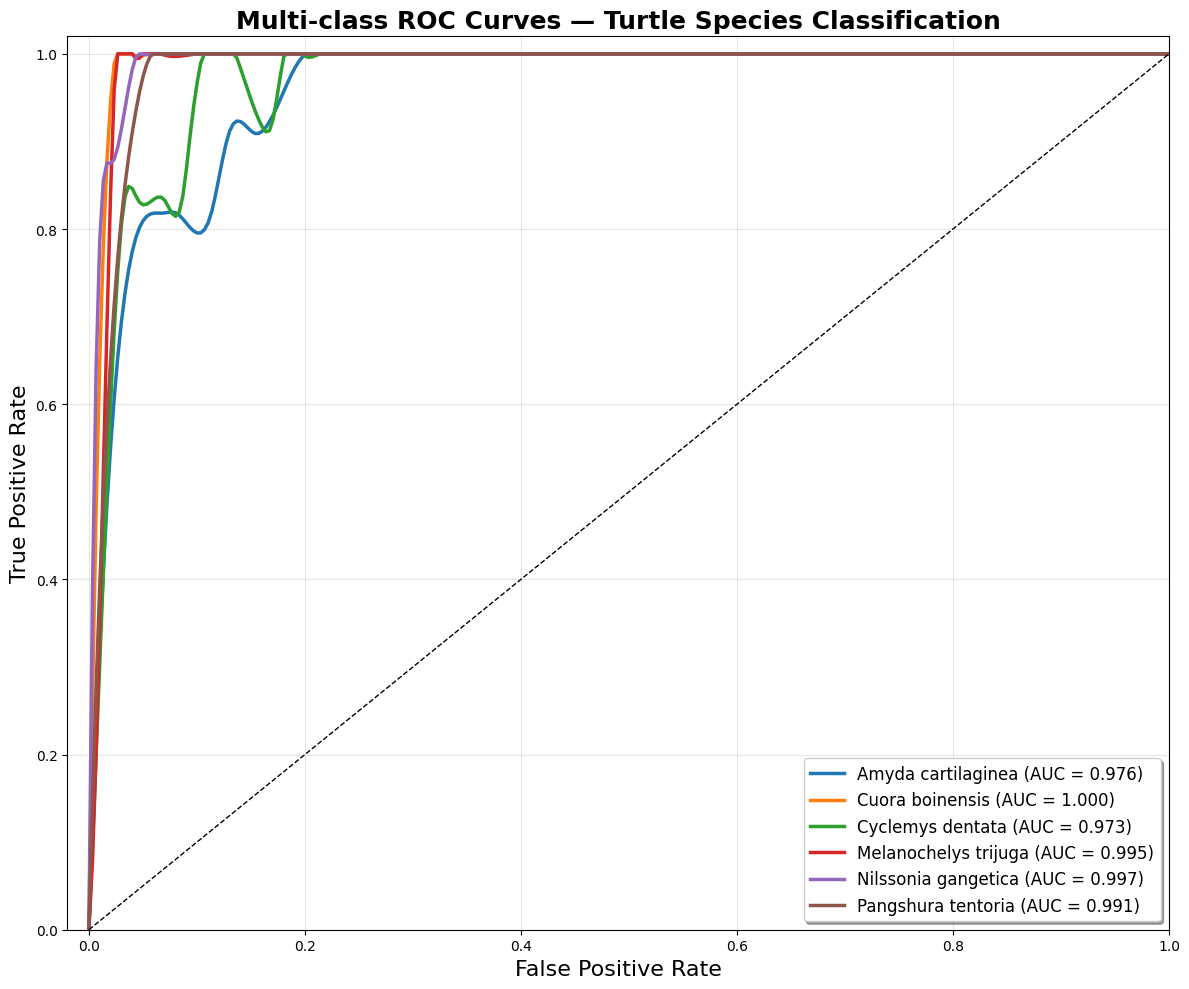

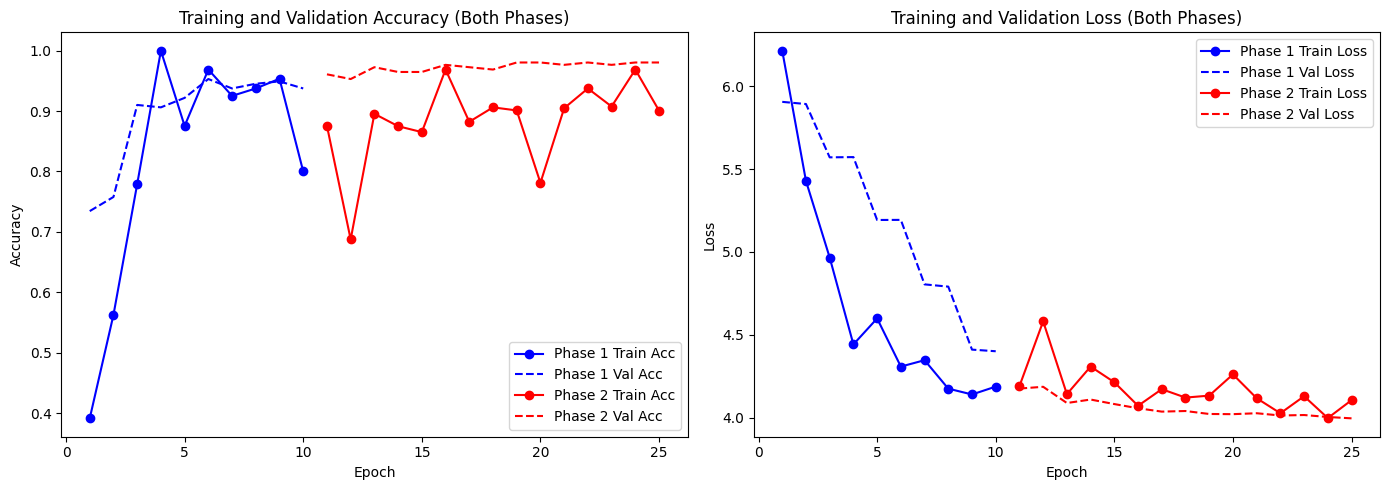

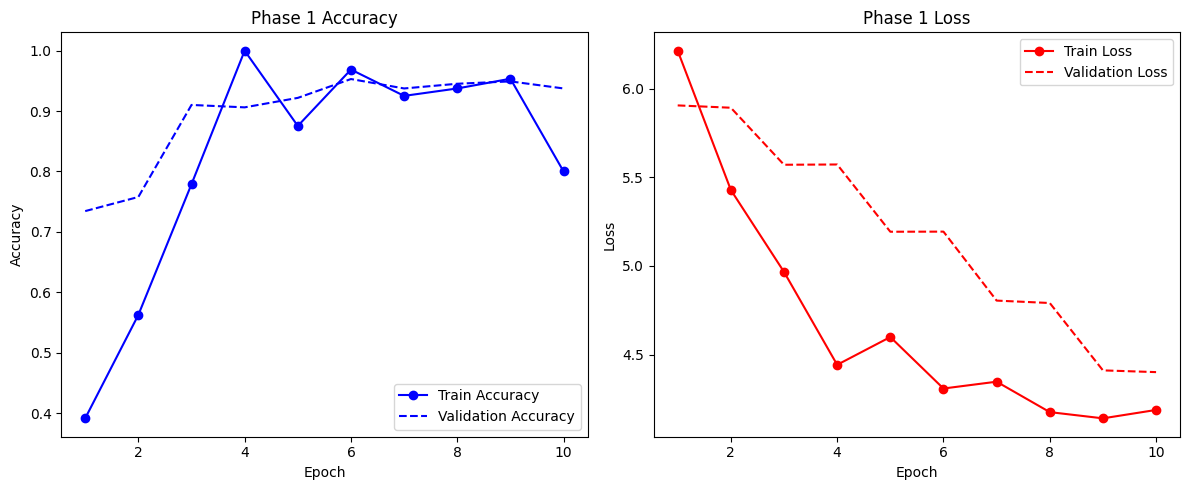

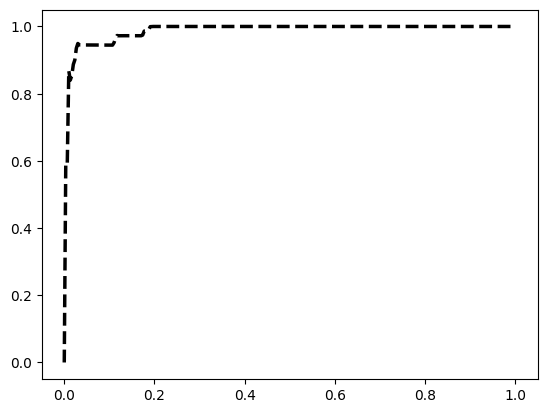

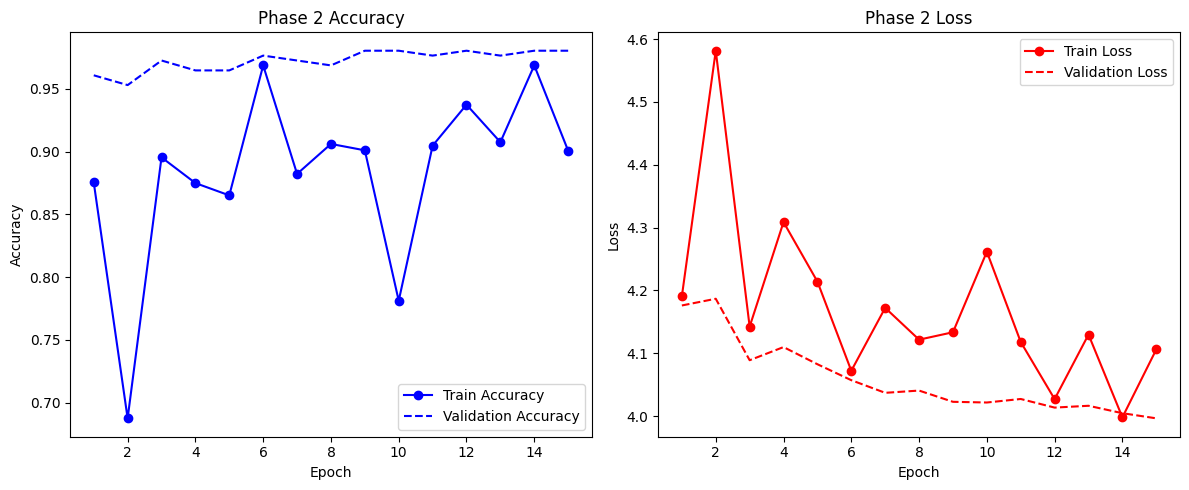

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from scipy.interpolate import make_interp_spline

# Load data
y_true = np.load('/content/drive/MyDrive/Turtle_classification_work/T_Net_B4_results/y_true.npy')
y_probs = np.load('/content/drive/MyDrive/Turtle_classification_work/T_Net_B4_results/y_probs.npy')

class_names = [
    'Amyda cartilaginea',
    'Cuora boinensis',
    'Cyclemys dentata',
    'Melanochelys trijuga',
    'Nilssonia gangetica',
    'Pangshura tentoria'
]
n_classes = len(class_names)

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(12, 10))
colors = plt.get_cmap('tab10').colors  # 10 distinct colors

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    fpr_unique, idx = np.unique(fpr, return_index=True)
    tpr_unique = tpr[idx]

    if len(fpr_unique) >= 4:
        fpr_smooth = np.linspace(fpr_unique.min(), fpr_unique.max(), 300)
        spline = make_interp_spline(fpr_unique, tpr_unique, k=3)
        tpr_smooth = spline(fpr_smooth)

        # Clip to [0, 1] range to avoid overshooting
        fpr_smooth = np.clip(fpr_smooth, 0, 1)
        tpr_smooth = np.clip(tpr_smooth, 0, 1)

        plt.plot(fpr_smooth, tpr_smooth, color=colors[i % len(colors)], lw=2.5,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    else:
        plt.plot(fpr_unique, tpr_unique, color=colors[i % len(colors)], lw=2.5,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

# Plot chance line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

# Axes and title
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('Multi-class ROC Curves — Turtle Species Classification', fontsize=18, fontweight='bold')
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save if needed
# plt.savefig('/content/drive/MyDrive/Turtle_classification_work/ROC_Multiclass_Turtles.png', dpi=300)

plt.show()



import matplotlib.pyplot as plt

# Phase 1 data (10 epochs)
phase1_acc = [0.3912, 0.5625, 0.7790, 1.0000, 0.8754, 0.9688, 0.9252, 0.9375, 0.9536, 0.8000]
phase1_val_acc = [0.7344, 0.7578, 0.9102, 0.9062, 0.9219, 0.9531, 0.9375, 0.9453, 0.9492, 0.9375]
phase1_loss = [6.2139, 5.4285, 4.9664, 4.4424, 4.5990, 4.3086, 4.3471, 4.1755, 4.1404, 4.1878]
phase1_val_loss = [5.9054, 5.8923, 5.5707, 5.5722, 5.1929, 5.1935, 4.8045, 4.7909, 4.4109, 4.4011]

# Phase 2 data (15 epochs)
phase2_acc = [0.8755, 0.6875, 0.8955, 0.8750, 0.8652, 0.9688, 0.8823, 0.9062, 0.9011, 0.7812, 0.9048, 0.9375, 0.9076, 0.9688, 0.9008]
phase2_val_acc = [0.9609, 0.9531, 0.9727, 0.9648, 0.9648, 0.9766, 0.9727, 0.9688, 0.9805, 0.9805, 0.9766, 0.9805, 0.9766, 0.9805, 0.9805]
phase2_loss = [4.1907, 4.5814, 4.1423, 4.3087, 4.2140, 4.0721, 4.1722, 4.1216, 4.1334, 4.2615, 4.1179, 4.0270, 4.1297, 3.9980, 4.1060]
phase2_val_loss = [4.1760, 4.1867, 4.0889, 4.1098, 4.0825, 4.0571, 4.0370, 4.0406, 4.0227, 4.0216, 4.0272, 4.0135, 4.0164, 4.0046, 3.9964]

# Epoch counts
phase1_epochs = range(1, len(phase1_acc) + 1)
phase2_epochs = range(1, len(phase2_acc) + 1)

# -------- Combined plot for both phases -----------
plt.figure(figsize=(14, 5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(phase1_epochs, phase1_acc, 'bo-', label='Phase 1 Train Acc')
plt.plot(phase1_epochs, phase1_val_acc, 'b--', label='Phase 1 Val Acc')
plt.plot([x + len(phase1_acc) for x in phase2_epochs], phase2_acc, 'ro-', label='Phase 2 Train Acc')
plt.plot([x + len(phase1_acc) for x in phase2_epochs], phase2_val_acc, 'r--', label='Phase 2 Val Acc')
plt.title('Training and Validation Accuracy (Both Phases)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(phase1_epochs, phase1_loss, 'bo-', label='Phase 1 Train Loss')
plt.plot(phase1_epochs, phase1_val_loss, 'b--', label='Phase 1 Val Loss')
plt.plot([x + len(phase1_loss) for x in phase2_epochs], phase2_loss, 'ro-', label='Phase 2 Train Loss')
plt.plot([x + len(phase1_loss) for x in phase2_epochs], phase2_val_loss, 'r--', label='Phase 2 Val Loss')
plt.title('Training and Validation Loss (Both Phases)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# -------- Separate plots for Phase 1 -----------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(phase1_epochs, phase1_acc, 'bo-', label='Train Accuracy')
plt.plot(phase1_epochs, phase1_val_acc, 'b--', label='Validation Accuracy')
plt.title('Phase 1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(phase1_epochs, phase1_loss, 'ro-', label='Train Loss')
plt.plot(phase1_epochs, phase1_val_loss, 'r--', label='Validation Loss')
plt.title('Phase 1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

from sklearn.metrics import roc_auc_score

# ====== Micro-Averaged ROC Curve ======
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Optional: smooth micro-average curve with spline
fpr_unique_micro, idx_micro = np.unique(fpr_micro, return_index=True)
tpr_unique_micro = tpr_micro[idx_micro]

if len(fpr_unique_micro) >= 4:
    fpr_smooth_micro = np.linspace(fpr_unique_micro.min(), fpr_unique_micro.max(), 300)
    spline_micro = make_interp_spline(fpr_unique_micro, tpr_unique_micro, k=3)
    tpr_smooth_micro = spline_micro(fpr_smooth_micro)
    x_vals_micro, y_vals_micro = fpr_smooth_micro, tpr_smooth_micro
else:
    x_vals_micro, y_vals_micro = fpr_unique_micro, tpr_unique_micro

# Plot micro-avg ROC
plt.plot(x_vals_micro, y_vals_micro, color='black', linestyle='--', lw=2.5,
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# -------- Separate plots for Phase 2 -----------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(phase2_epochs, phase2_acc, 'bo-', label='Train Accuracy')
plt.plot(phase2_epochs, phase2_val_acc, 'b--', label='Validation Accuracy')
plt.title('Phase 2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(phase2_epochs, phase2_loss, 'ro-', label='Train Loss')
plt.plot(phase2_epochs, phase2_val_loss, 'r--', label='Validation Loss')
plt.title('Phase 2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
# Install required packages (if not already installed)
!pip install -q tensorflow matplotlib

from google.colab import drive
drive.mount('/content/drive')

# Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# ✅ Load pretrained EfficientNetB4
base_model = tf.keras.applications.EfficientNetB4(weights='imagenet', include_top=False)

from tensorflow.keras import backend as K

for idx, layer in enumerate(base_model.layers):
    try:
        print(f"{idx}: {layer.name} - {K.int_shape(layer.output)}")
    except:
        print(f"{idx}: {layer.name} - Output shape not available")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
0: input_layer_2 - (None, None, None, 3)
1: rescaling_4 - (None, None, None, 3)
2: normalization_2 - (None, None, None, 3)
3: rescaling_5 - (None, None, None, 3)
4: stem_conv_pad - (None, None, None, 3)
5: stem_conv - (None, None, None, 48)
6: stem_bn - (None, None, None, 48)
7: stem_activation - (None, None, None, 48)
8: block1a_dwconv - (None, None, None, 48)
9: block1a_bn - (None, None, None, 48)
10: block1a_activation - (None, None, None, 48)
11: block1a_se_squeeze - (None, 48)
12: block1a_se_reshape - (None, 1, 1, 48)
13: block1a_se_reduce - (None, 1, 1, 12)
14: block1a_se_expand - (None, 1, 1, 48)
15: block1a_se_excite - (None, None, None, 48)
16: block1a_project_conv - (None, None, None, 24)
17: block1a_project_bn - (None, None, None, 24)
18: block1b_dwconv - (None, None, None, 24)
19: block1b_bn - (None, None, None, 24)
20: block1b_activation - (None,

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


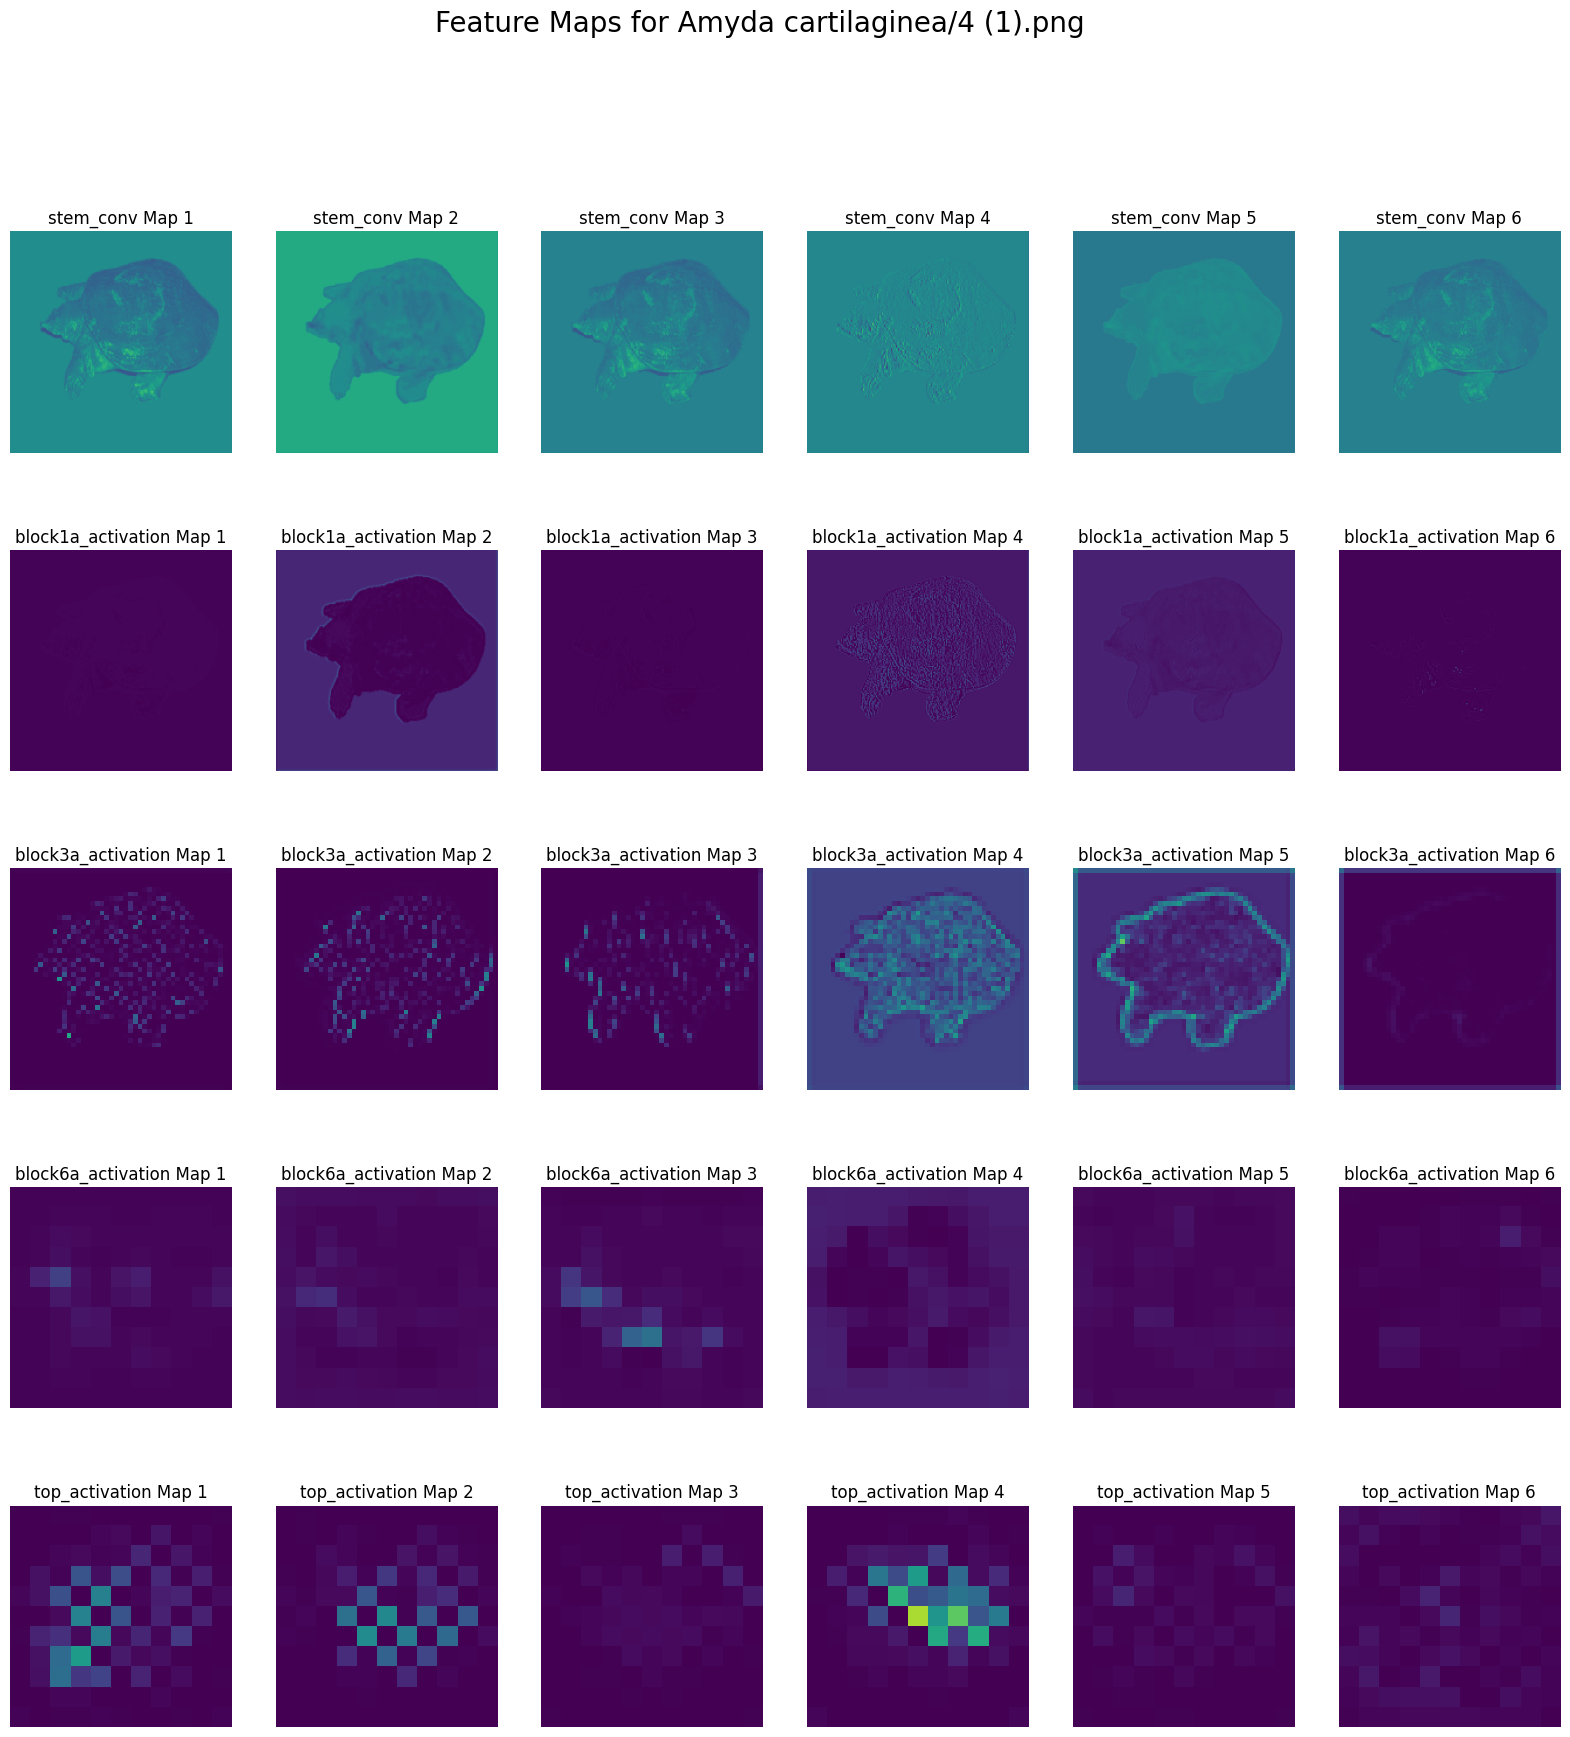

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


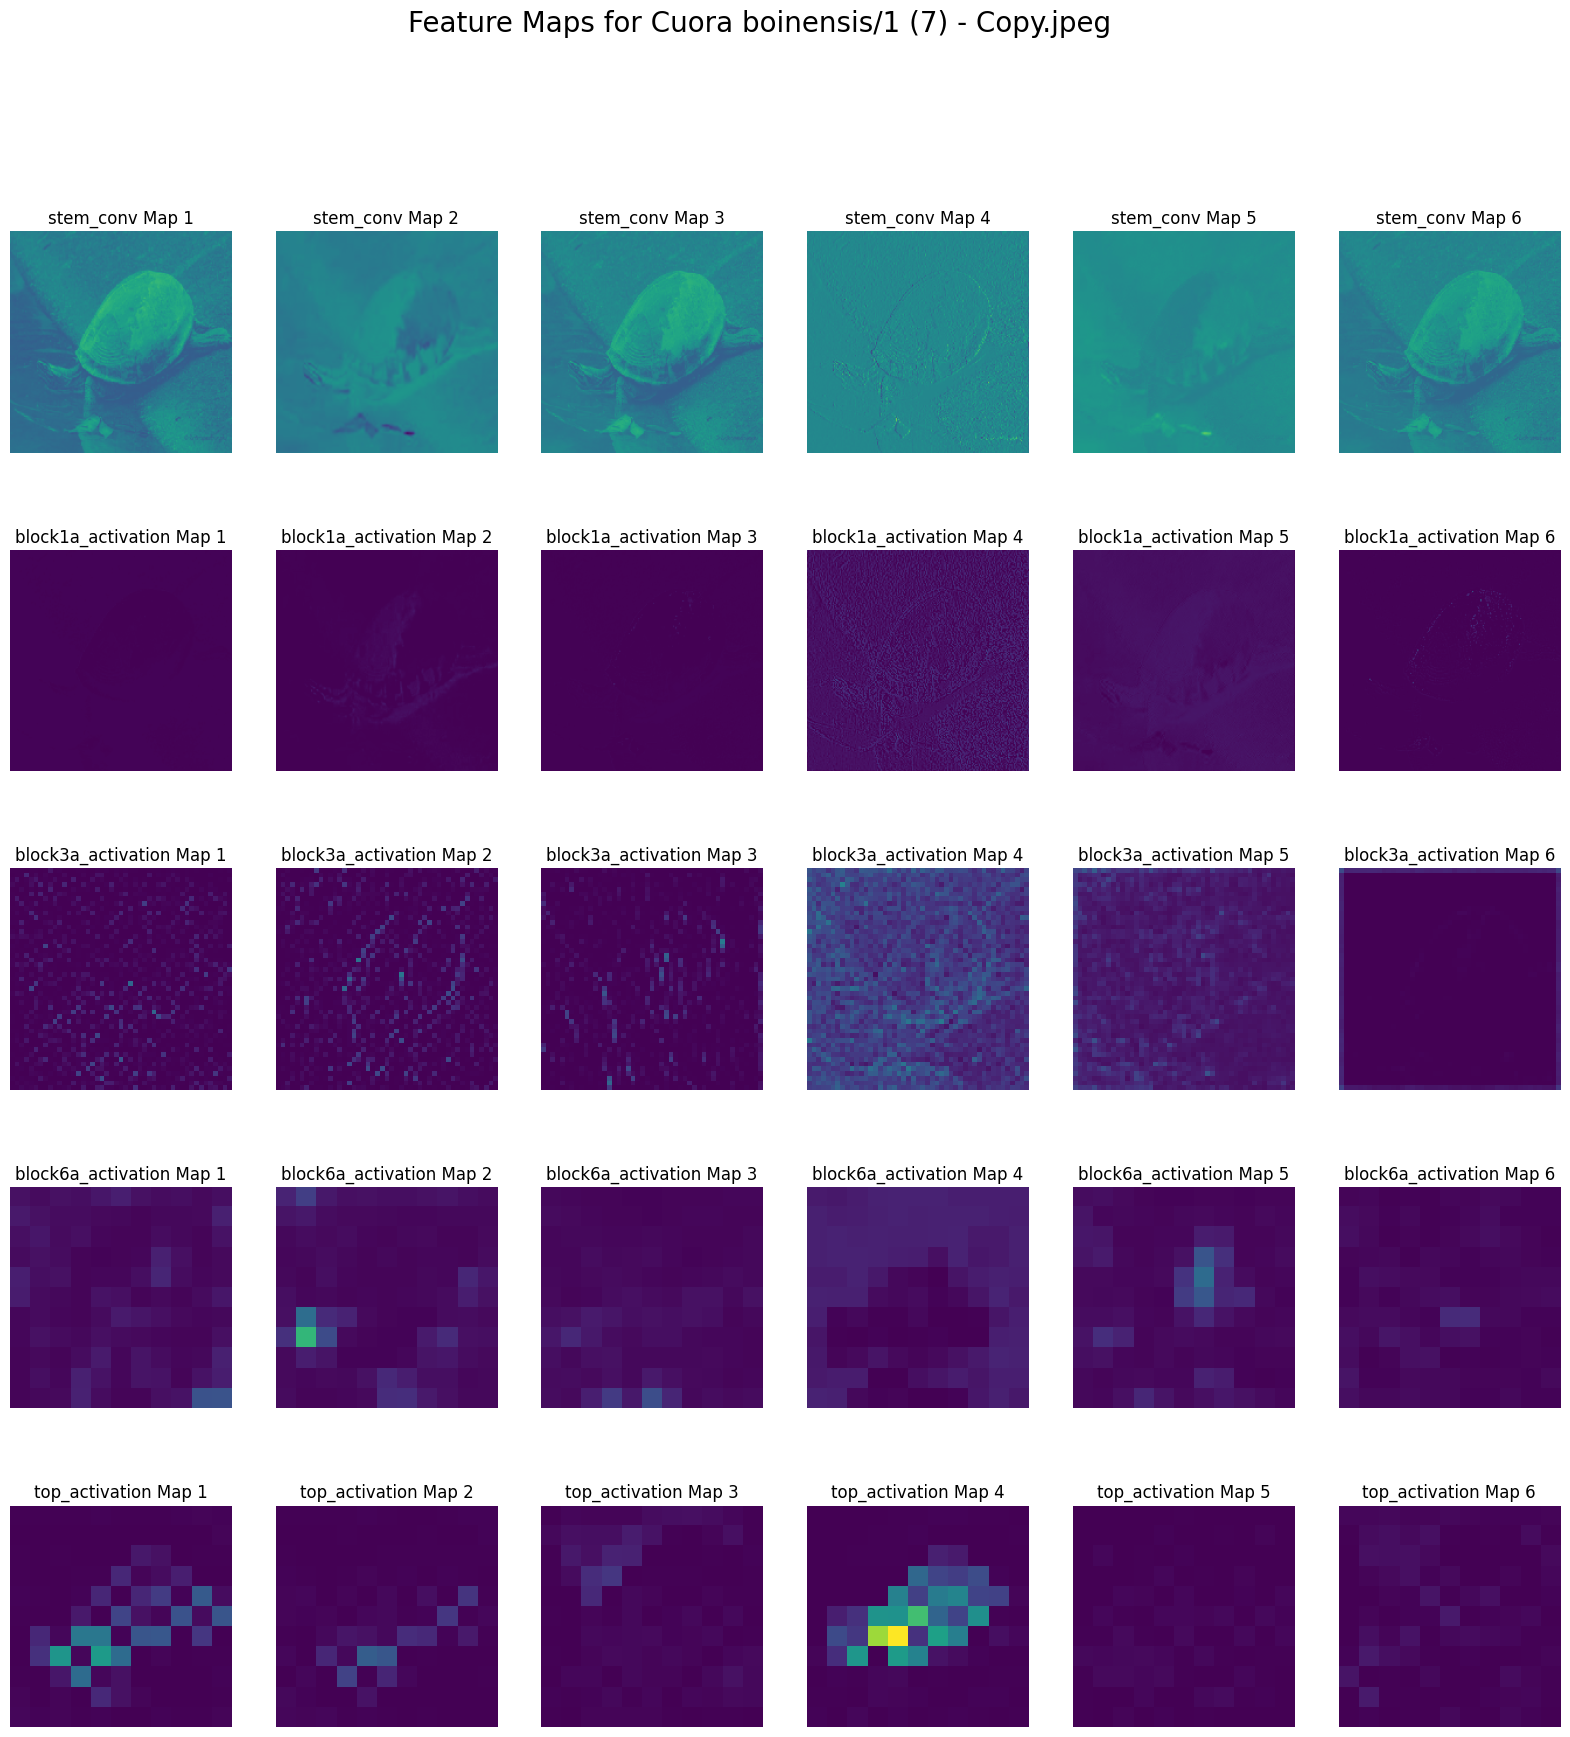

NotADirectoryError: [Errno 20] Not a directory: '/content/drive/MyDrive/Dataset/Training/Cyclemys dentata/24d437ac7150a767a4d5a9bf4ef3241b - Copy - Copy - Copy.jpeg/content/drive/MyDrive/Dataset/Training/Melanochelys trijuga/6_529-210-59a1b4814c7fc-1 - Copy.jpg/content/drive/MyDrive/Dataset/Training/Nilssonia gangetica/8427f873abe02e9c710481a22d123dac - Copy (2) - Copy.jpeg/content/drive/MyDrive/Dataset/Training/Pangshura tentoria/6aa167e043e02f3696a5f9375e8370ec - Copy (3).jpeg/content/drive/MyDrive/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training/Box_turtle/0CWE50ED17FV.jpg/content/drive/MyDrive/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training/Leatherback_turtle/0F4U07BU7T9B.jpg/content/drive/MyDrive/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training/Loggerhead_turtle/0YUL2DB8DREX.jpg/content/drive/MyDrive/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training/Mud_turtle/0EY0RAPEQVVN.jpg'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# Select the most informative layers to extract feature maps
layer_names = [
    'stem_conv',            # Early stage: edge detection
    'block1a_activation',   # Early-mid stage: simple patterns
    'block3a_activation',   # Mid stage: more abstract features
    'block6a_activation',   # Mid-late stage: semantic patterns
    'top_activation'        # Late stage: high-level abstractions
]

# Build the feature extraction model
outputs = [base_model.get_layer(name).output for name in layer_names]
activation_model = Model(inputs=base_model.input, outputs=outputs)

# List of image paths
img_paths = [
    '/content/drive/MyDrive/Dataset/Testing/Amyda cartilaginea/4 (1).png',
    '/content/drive/MyDrive/Dataset/Testing/Cuora boinensis/1 (7) - Copy.jpeg',
    '/content/drive/MyDrive/Dataset/Training/Cyclemys dentata/24d437ac7150a767a4d5a9bf4ef3241b - Copy - Copy - Copy.jpeg'
    '/content/drive/MyDrive/Dataset/Training/Melanochelys trijuga/6_529-210-59a1b4814c7fc-1 - Copy.jpg'
     '/content/drive/MyDrive/Dataset/Training/Nilssonia gangetica/8427f873abe02e9c710481a22d123dac - Copy (2) - Copy.jpeg'
      '/content/drive/MyDrive/Dataset/Training/Pangshura tentoria/6aa167e043e02f3696a5f9375e8370ec - Copy (3).jpeg'
       '/content/drive/MyDrive/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training/Box_turtle/0CWE50ED17FV.jpg'
        '/content/drive/MyDrive/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training/Leatherback_turtle/0F4U07BU7T9B.jpg'
           '/content/drive/MyDrive/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training/Loggerhead_turtle/0YUL2DB8DREX.jpg'
           '/content/drive/MyDrive/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training/Mud_turtle/0EY0RAPEQVVN.jpg'



    # Add more image paths as needed
]

# Plot feature maps function
def plot_feature_maps(feature_maps, layer_names, img_path, num_maps=6):
    num_layers = len(feature_maps)
    plt.figure(figsize=(20, num_layers * 4))
    plot_index = 1
    for layer_index in range(num_layers):
        fmap = feature_maps[layer_index][0]
        fmap_min = np.min(fmap)
        fmap_max = np.max(fmap)
        for i in range(num_maps):
            if i >= fmap.shape[-1]:
                break
            plt.subplot(num_layers, num_maps, plot_index)
            plt.imshow(fmap[:, :, i], cmap='viridis', vmin=fmap_min, vmax=fmap_max)
            plt.axis('off')
            plt.title(f"{layer_names[layer_index]} Map {i+1}")
            plot_index += 1
    plt.suptitle(f"Feature Maps for {img_path.split('/')[-2]}/{img_path.split('/')[-1]}", fontsize=20)
    plt.show()

# Loop through each image and visualize
for img_path in img_paths:
    # Preprocess the image
    img = image.load_img(img_path, target_size=(380, 380))
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Get feature maps
    feature_maps = activation_model.predict(img_array)

    # Plot feature maps
    plot_feature_maps(feature_maps, layer_names, img_path, num_maps=6)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from google.colab import files

# Select the most informative layers to extract feature maps
layer_names = [
    'stem_conv',            # Early stage: edge detection
    'block1a_activation',   # Early-mid stage: simple patterns
    'block3a_activation',   # Mid stage: more abstract features
    'block6a_activation',   # Mid-late stage: semantic patterns
    'top_activation'        # Late stage: high-level abstractions
]

# Build the feature extraction model
outputs = [base_model.get_layer(name).output for name in layer_names]
activation_model = Model(inputs=base_model.input, outputs=outputs)

# Plot feature maps function
def plot_feature_maps(feature_maps, layer_names, img_path, num_maps=6):
    num_layers = len(feature_maps)
    plt.figure(figsize=(20, num_layers * 4))
    plot_index = 1
    for layer_index in range(num_layers):
        fmap = feature_maps[layer_index][0]
        fmap_min = np.min(fmap)
        fmap_max = np.max(fmap)
        for i in range(num_maps):
            if i >= fmap.shape[-1]:
                break
            plt.subplot(num_layers, num_maps, plot_index)
            plt.imshow(fmap[:, :, i], cmap='viridis', vmin=fmap_min, vmax=fmap_max)
            plt.axis('off')
            plt.title(f"{layer_names[layer_index]} Map {i+1}")
            plot_index += 1
    plt.suptitle(f"Feature Maps for {img_path}", fontsize=20)
    plt.show()

# Manual upload and loop
while True:
    print("\nPlease upload an image (or press Stop to end):")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded. Exiting loop.")
        break

    for img_path in uploaded.keys():
        print(f"\nProcessing: {img_path}")
        # Preprocess the image
        img = image.load_img(img_path, target_size=(380, 380))
        img_array = image.img_to_array(img)
        img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        # Get feature maps
        feature_maps = activation_model.predict(img_array)

        # Plot feature maps
        plot_feature_maps(feature_maps, layer_names, img_path, num_maps=6)

    # Ask whether to continue
    cont = input("\nDo you want to upload another image? (y/n): ")
    if cont.lower() != 'y':
        print("Exiting...")
        break


Output hidden; open in https://colab.research.google.com to view.

Saving Amyda cartilaginea.jpeg to Amyda cartilaginea (1).jpeg
Feature Vector Shape: (1792,)


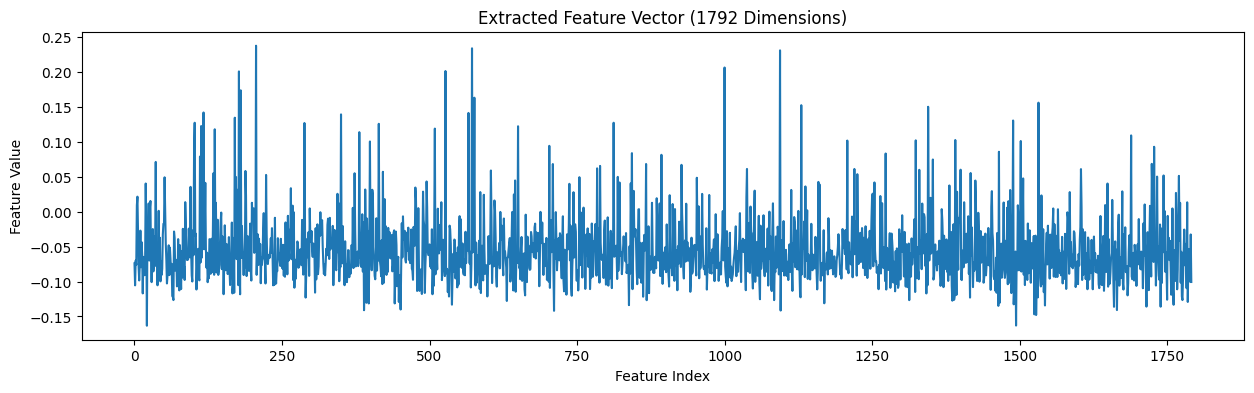

In [ ]:
!pip install -q timm
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import timm
from google.colab import files
# Load EfficientNetB4 without the classification head
model = timm.create_model('efficientnet_b4', pretrained=True)
model.classifier = nn.Identity()  # Remove the final classification layer
model.eval()
# EfficientNetB4 preprocessing
transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
# Upload image manually
uploaded = files.upload()

# Load the uploaded image
image_path = list(uploaded.keys())[0]
img = Image.open(image_path).convert('RGB')
# Preprocess the image
input_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Pass through the model
with torch.no_grad():
    features = model(input_tensor)

# Get the 1D feature vector
feature_vector = features.squeeze().numpy()
print('Feature Vector Shape:', feature_vector.shape)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(feature_vector)
plt.title('Extracted Feature Vector (1792 Dimensions)')
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.show()



Saving Amyda cartilaginea.jpeg to Amyda cartilaginea (2).jpeg
Feature Vector Shape: (1792,)


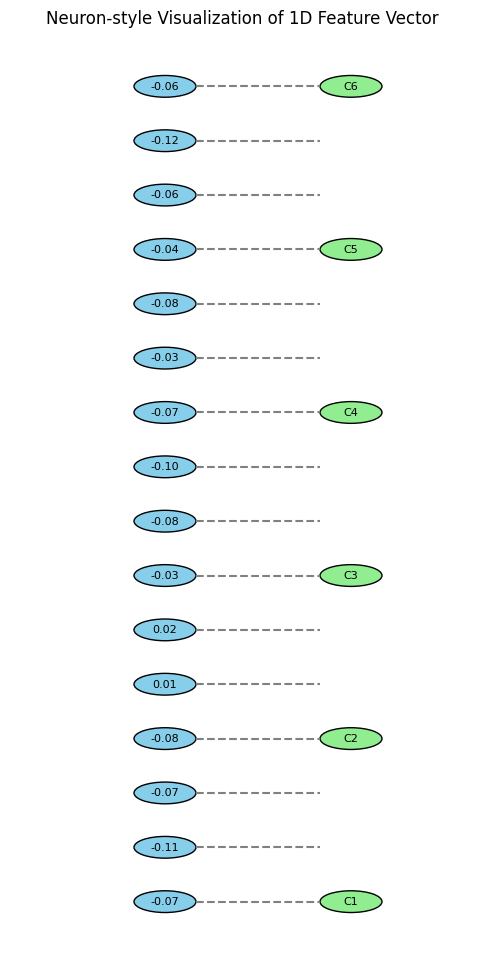

In [ ]:
# Install dependencies
!pip install -q timm
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import timm
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np

# Load EfficientNetB4 without the classification head
model = timm.create_model('efficientnet_b4', pretrained=True)
model.classifier = nn.Identity()  # Remove the final classification layer
model.eval()

# EfficientNetB4 preprocessing
transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Upload image manually
uploaded = files.upload()

# Load the uploaded image
image_path = list(uploaded.keys())[0]
img = Image.open(image_path).convert('RGB')

# Preprocess the image
input_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Pass through the model
with torch.no_grad():
    features = model(input_tensor)

# Get the 1D feature vector
feature_vector = features.squeeze().numpy()
print('Feature Vector Shape:', feature_vector.shape)

# Plot Neuron-Style Visualization (first 16 neurons for clarity)
subset_size = 16  # You can increase this but visualization may get crowded
subset_vector = feature_vector[:subset_size]

fig, ax = plt.subplots(figsize=(6, 12))

# Plot neurons (circles)
for i, val in enumerate(subset_vector):
    circle = plt.Circle((0, i), 0.2, color='skyblue', ec='black')
    ax.add_patch(circle)
    ax.text(0, i, f'{val:.2f}', fontsize=8, ha='center', va='center')

# Optionally, draw connections to a classification layer (mocked here)
for i in range(subset_size):
    ax.plot([0.2, 1.0], [i, i], color='gray', linestyle='--')  # Connection lines

# Draw classification layer nodes (mock 6 classes)
class_nodes = 6
for j in range(class_nodes):
    circle = plt.Circle((1.2, (subset_size - 1) * j / (class_nodes - 1)), 0.2, color='lightgreen', ec='black')
    ax.add_patch(circle)
    ax.text(1.2, (subset_size - 1) * j / (class_nodes - 1), f'C{j+1}', fontsize=8, ha='center', va='center')

plt.xlim(-1, 2)
plt.ylim(-1, subset_size)
plt.axis('off')
plt.title('Neuron-style Visualization of 1D Feature Vector')
plt.show()


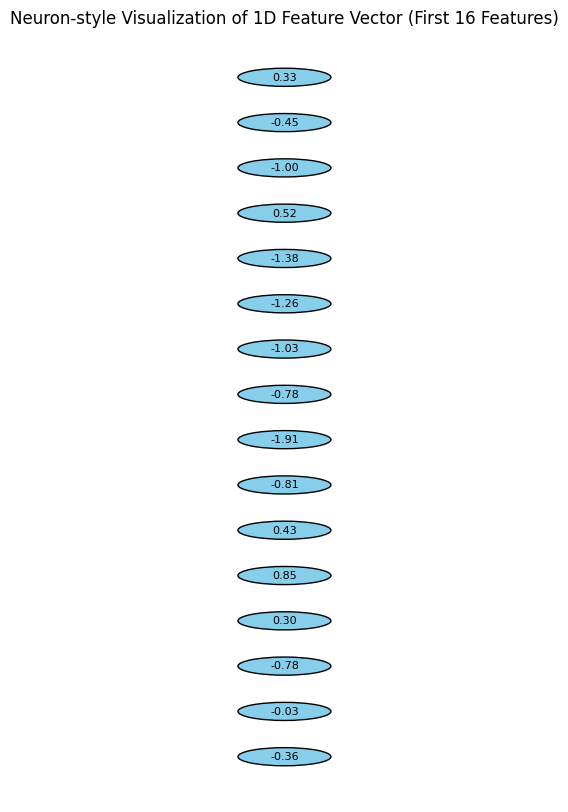

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example feature vector
feature_vector = np.random.randn(1792)  # Replace this with your actual extracted vector

# Select a subset to visualize clearly (e.g., first 16 elements)
subset_size = 16
subset_vector = feature_vector[:subset_size]

fig, ax = plt.subplots(figsize=(6, 10))

# Plot each feature as a neuron
for i, val in enumerate(subset_vector):
    # Draw a circle for each neuron
    circle = plt.Circle((0, i), 0.2, color='skyblue', ec='black')
    ax.add_patch(circle)
    # Display the feature value inside the neuron
    ax.text(0, i, f'{val:.2f}', fontsize=8, ha='center', va='center')

# Formatting the plot
plt.xlim(-1, 1)
plt.ylim(-1, subset_size)
plt.axis('off')
plt.title('Neuron-style Visualization of 1D Feature Vector (First 16 Features)')
plt.show()


In [ ]:
# Install required packages (if not already installed)
!pip install -q tensorflow matplotlib

from google.colab import drive
drive.mount('/content/drive')

# Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# Load your trained model
model = tf.keras.models.load_model('/content/drive/MyDrive/Turtle_Net-B4.h5', compile=False)

# Select an image path of a turtle you want to visualize (change as needed)
img_path = '/content/drive/MyDrive/Dataset/Testing/Amyda cartilaginea/4 (1).png'  # Replace with your actual image path

# Preprocess image
img = image.load_img(img_path, target_size=(380, 380))
img_array = image.img_to_array(img)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# ✅ Manually pick layer names (you can inspect model.summary())
# Example: Take stem_conv_pad and stem_conv (commonly valid in EfficientNet)
layer_names = ['stem_conv_pad', 'stem_conv']  # You can replace/add layer names based on your model summary

# Build activation model with only selected layers
outputs = [model.get_layer(name).output for name in layer_names]
activation_model = Model(inputs=model.input, outputs=outputs)

# Get feature maps
feature_maps = activation_model.predict(img_array)

# Plot feature maps
def plot_feature_maps(feature_maps, layer_names, num_maps=6):
    num_layers = len(feature_maps)
    plt.figure(figsize=(20, num_layers * 4))
    plot_index = 1
    for layer_index in range(num_layers):
        fmap = feature_maps[layer_index][0]
        fmap_min = np.min(fmap)
        fmap_max = np.max(fmap)
        for i in range(num_maps):
            if i >= fmap.shape[-1]:
                break
            plt.subplot(num_layers, num_maps, plot_index)
            plt.imshow(fmap[:, :, i], cmap='viridis', vmin=fmap_min, vmax=fmap_max)
            plt.axis('off')
            plt.title(f"{layer_names[layer_index]} Map {i+1}")
            plot_index += 1
    plt.suptitle(f"Feature Maps for {img_path.split('/')[-2]}", fontsize=20)
    plt.show()

# Plot the feature maps
plot_feature_maps(feature_maps, layer_names, num_maps=6)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ValueError: No such layer: stem_conv_pad. Existing layers are: ['input_layer_9', 'efficientnetb4', 'global_average_pooling2d_8', 'dense_16', 'dense_17', 'multiply_4', 'global_average_pooling2d_9', 'dense_18', 'batch_normalization_4', 'dropout_4', 'dense_19'].

In [ ]:
!ls '/content/drive/MyDrive'


ls: cannot access '/content/drive/MyDrive': No such file or directory


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2053 images belonging to 6 classes.
Found 286 images belonging to 6 classes.
Found 291 images belonging to 6 classes.
Phase 1: Training custom head (base frozen)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 913ms/step - accuracy: 0.3536 - loss: 6.3260 - val_accuracy: 0.7500 - val_loss: 5.9048
Epoch 2/10
 1/64 ━━━━━━━━━━━━━━━━━━━━ 14s 234ms/step - accuracy: 0.5938 - loss: 5.4761

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 237ms/step - accuracy: 0.5938 - loss: 5.4761 - val_accuracy: 0.7578 - val_loss: 5.8995
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 631ms/step - accuracy: 0.7847 - loss: 4.9663 - val_accuracy: 0.8906 - val_loss: 5.5767
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.7500 - loss: 4.8625 - val_accuracy: 0.8906 - val_loss: 5.5672
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 425ms/step - accuracy: 0.8760 - loss: 4.6149 - val_accuracy: 0.9180 - val_loss: 5.2008
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9062 - loss: 4.4557 - val_accuracy: 0.9180 - val_loss: 5.1972
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 500ms/step - accuracy: 0.9208 - loss: 4.3692 - val_accuracy: 0.9258 - val_loss: 4.8185
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9062 - loss: 4.2390 - val_accuracy: 0.9258 - val_loss: 4.8212
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 404ms/step - accuracy: 0.9427 - loss: 4.1603 - val_accuracy: 0.8945 - va

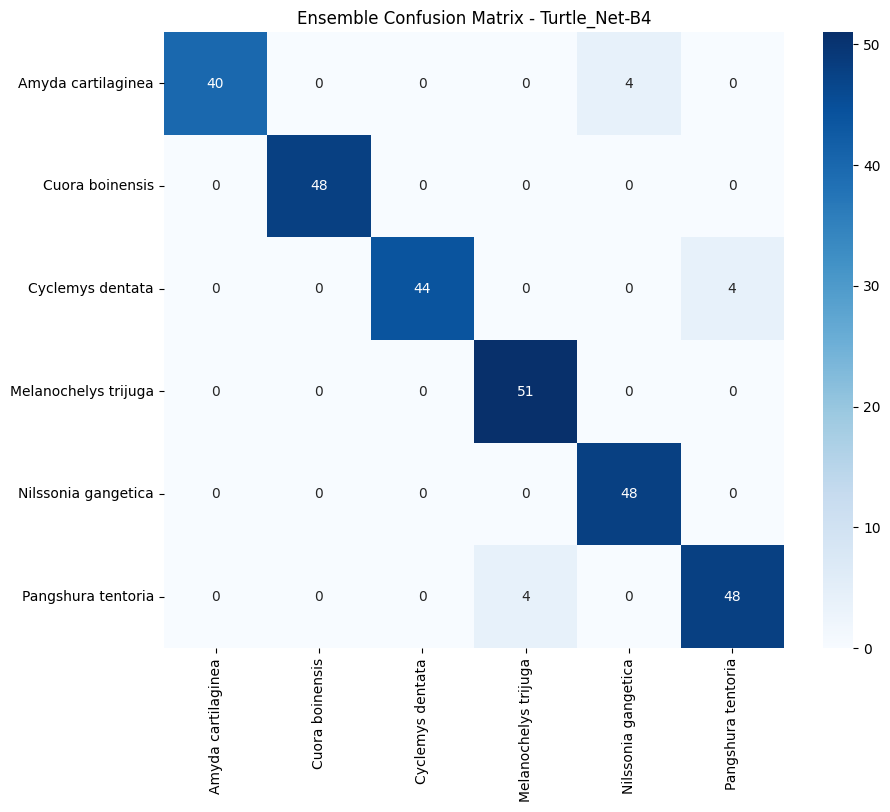

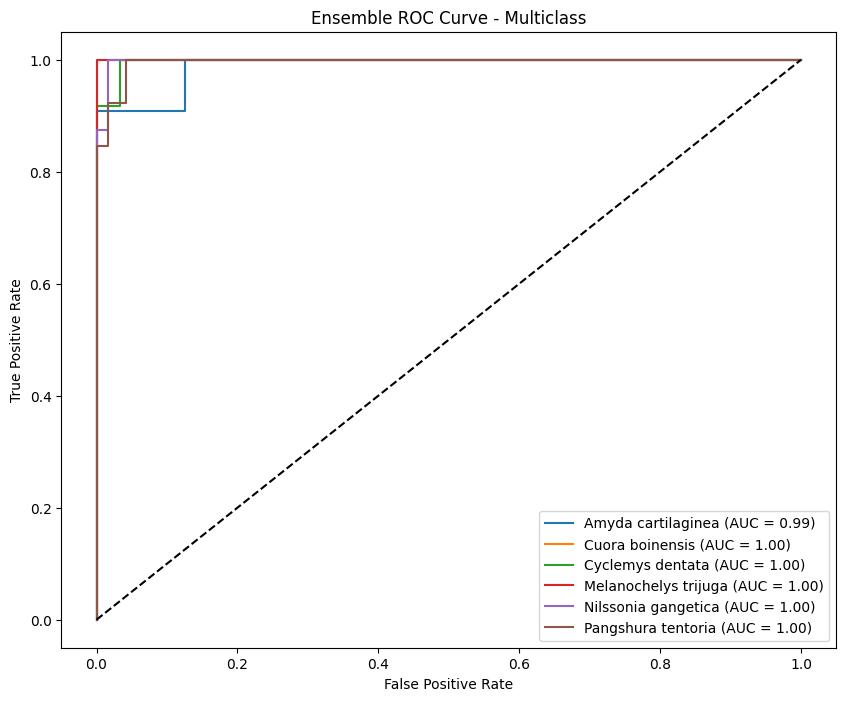

Ensemble model saved to Google Drive!

Total execution time: 0h 13m 42s


In [ ]:
# Install required packages
!pip install -q tensorflow scikit-learn seaborn

# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from google.colab import drive

# Start execution timer
start_time = time.time()

# Mount Google Drive
drive.mount('/content/drive')

# Dataset paths
train_dir = '/content/drive/MyDrive/Dataset/Training'
validation_dir = '/content/drive/MyDrive/Dataset/Validation'
test_dir = '/content/drive/MyDrive/Dataset/Testing'

# Data generators
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# Load datasets
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Custom Squeeze-and-Excitation (SE) Block
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

# Load EfficientNetB4 (frozen initially)
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(380, 380, 3),
    pooling=None
)
base_model.trainable = False

# Build custom model
inputs = tf.keras.Input(shape=(380, 380, 3))
x = base_model(inputs, training=False)
x = se_block(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation='softmax')(x)

custom_model = tf.keras.models.Model(inputs, outputs, name="Turtle_Net-B4")  # Explicitly use tf.keras.models

# Setup checkpoint directory
checkpoint_dir = '/content/drive/MyDrive/Turtle_Net_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Updated TopNCheckpoints callback class
class TopNCheckpoints(callbacks.Callback):
    def __init__(self, n=4):
        super().__init__()
        self.n = n
        self.best_checkpoints = []  # Stores (val_accuracy, filepath) tuples

    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('val_accuracy')
        filepath = os.path.join(checkpoint_dir, f'epoch_{epoch+1}_valacc_{current_acc:.4f}.weights.h5')

        if len(self.best_checkpoints) < self.n:
            self.model.save_weights(filepath)
            self.best_checkpoints.append((current_acc, filepath))
        else:
            min_acc = min(x[0] for x in self.best_checkpoints)
            if current_acc > min_acc:
                # Remove the lowest accuracy checkpoint
                _, removed_file = self.best_checkpoints.pop(self.best_checkpoints.index(min(self.best_checkpoints)))
                try:
                    os.remove(removed_file)
                except:
                    pass
                # Save new checkpoint
                self.model.save_weights(filepath)
                self.best_checkpoints.append((current_acc, filepath))

top_n_checkpoint = TopNCheckpoints(n=4)

# Phase 1: Train only the custom head
custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training custom head (base frozen)")
history_phase1 = custom_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10,
    callbacks=[top_n_checkpoint],
    verbose=1
)

# Phase 2: Fine-tune top layers of EfficientNetB4
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: Fine-tuning top layers")
history_phase2 = custom_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=15,
    callbacks=[top_n_checkpoint],
    verbose=1
)

# Ensemble predictions from top checkpoints
print("\nLoading top checkpoints for ensemble prediction...")
model_list = []  # Changed variable name to avoid conflict
for _, filepath in sorted(top_n_checkpoint.best_checkpoints, key=lambda x: x[0], reverse=True):
    # Explicitly use tf.keras.models
    model = tf.keras.models.Model(inputs, outputs, name="Turtle_Net-B4")
    model.load_weights(filepath)
    model_list.append(model)
    print(f"Loaded checkpoint: {os.path.basename(filepath)}")

# Generate ensemble predictions
test_generator.reset()
y_probs_list = []
for model in model_list:
    y_probs_list.append(model.predict(test_generator))

# Average predictions
y_probs_ensemble = np.mean(y_probs_list, axis=0)
y_pred_ensemble = np.argmax(y_probs_ensemble, axis=1)
y_true = test_generator.classes

# Metrics for ensemble
test_acc = accuracy_score(y_true, y_pred_ensemble)
precision = precision_score(y_true, y_pred_ensemble, average='weighted')
recall = recall_score(y_true, y_pred_ensemble, average='weighted')
f1 = f1_score(y_true, y_pred_ensemble, average='weighted')

print(f"\nEnsemble Test Accuracy: {test_acc*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

# Classification report
print("\nEnsemble Classification Report:")
print(classification_report(y_true, y_pred_ensemble, target_names=list(test_generator.class_indices.keys())))

# Confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred_ensemble),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Ensemble Confusion Matrix - Turtle_Net-B4')
plt.show()

# ROC Curve for ensemble
plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_true, classes=np.arange(len(test_generator.class_indices)))

for i in range(len(test_generator.class_indices)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs_ensemble[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{list(test_generator.class_indices.keys())[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble ROC Curve - Multiclass')
plt.legend(loc='lower right')
plt.show()

# Save final ensemble model
ensemble_model = tf.keras.models.Model(inputs, outputs, name="Turtle_Net-B4-Ensemble")
ensemble_model.set_weights(model_list[0].get_weights())  # Initialize with first model's weights
ensemble_model.save("/content/drive/MyDrive/Turtle_Net-B4_Ensemble.h5")
print("Ensemble model saved to Google Drive!")

# Print execution time
end_time = time.time()
total_time = end_time - start_time
hours, remainder = divmod(total_time, 3600)
minutes, seconds = divmod(remainder, 60)
print(f"\nTotal execution time: {int(hours)}h {int(minutes)}m {int(seconds)}s")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2053 images belonging to 6 classes.
Found 286 images belonging to 6 classes.
Found 291 images belonging to 6 classes.
Phase 1: Training custom head (base frozen)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.3873 - loss: 6.2894 - val_accuracy: 0.8242 - val_loss: 5.8858
Epoch 2/10
 1/64 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - accuracy: 0.8125 - loss: 4.9468

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.8125 - loss: 4.9468 - val_accuracy: 0.8086 - val_loss: 5.8791
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 629ms/step - accuracy: 0.7941 - loss: 4.9323 - val_accuracy: 0.8867 - val_loss: 5.5266
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9062 - loss: 4.6551 - val_accuracy: 0.8945 - val_loss: 5.5237
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 704ms/step - accuracy: 0.8980 - loss: 4.5684 - val_accuracy: 0.9336 - val_loss: 5.1656
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9062 - loss: 4.4458 - val_accuracy: 0.9453 - val_loss: 5.1484
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 442ms/step - accuracy: 0.9203 - loss: 4.3601 - val_accuracy: 0.9414 - val_loss: 4.7454
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.8750 - loss: 4.2368 - val_accuracy: 0.9453 - val_loss: 4.7346
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 523ms/step - accuracy: 0.9349 - loss: 4.1552 - val_accuracy: 0.9648 - val_

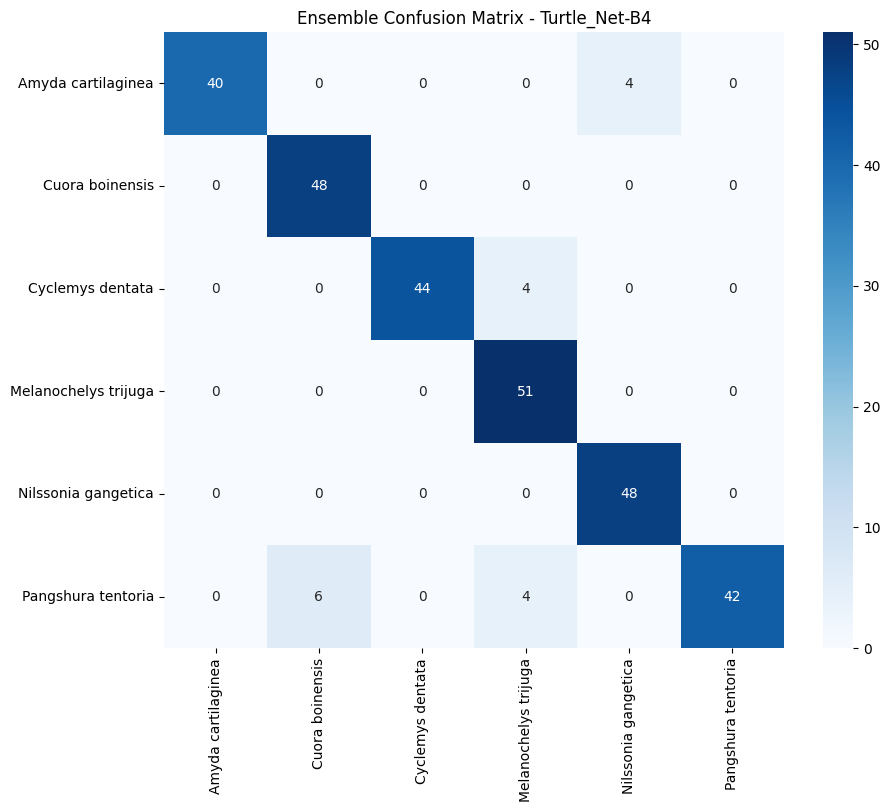

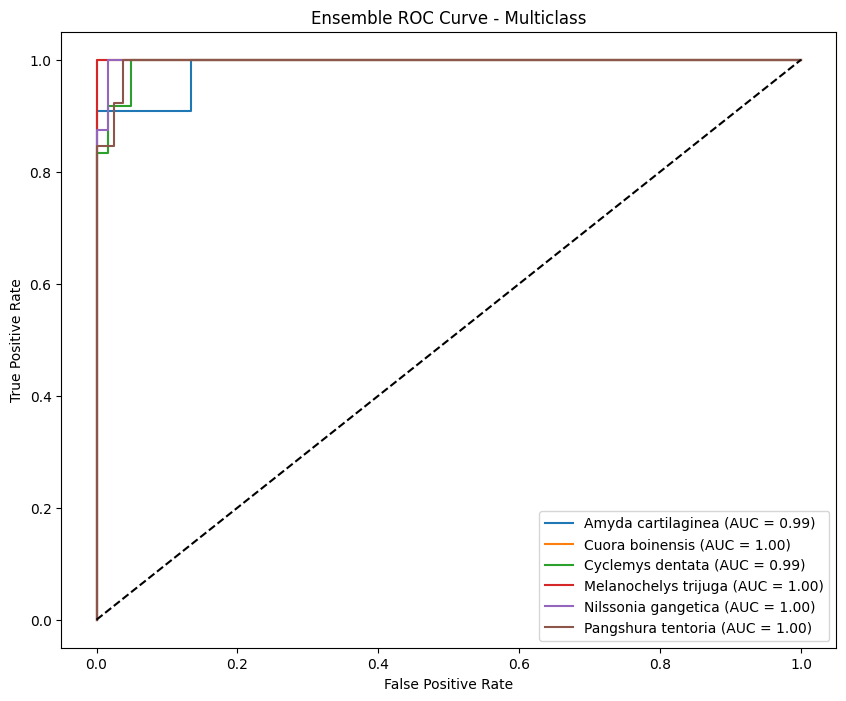

Ensemble model saved to Google Drive!

Total execution time: 0h 15m 31s


In [ ]:
# Install required packages
!pip install -q tensorflow scikit-learn seaborn

# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from google.colab import drive

# Start execution timer
start_time = time.time()

# Mount Google Drive
drive.mount('/content/drive')

# Dataset paths
train_dir = '/content/drive/MyDrive/Dataset/Training'
validation_dir = '/content/drive/MyDrive/Dataset/Validation'
test_dir = '/content/drive/MyDrive/Dataset/Testing'

# Data generators
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# Load datasets
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Custom Squeeze-and-Excitation (SE) Block
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

# Load EfficientNetB4 (frozen initially)
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(380, 380, 3),
    pooling=None
)
base_model.trainable = False

# Build custom model
inputs = tf.keras.Input(shape=(380, 380, 3))
x = base_model(inputs, training=False)
x = se_block(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation='softmax')(x)

custom_model = tf.keras.models.Model(inputs, outputs, name="Turtle_Net-B4")  # Explicitly use tf.keras.models

# Setup checkpoint directory
checkpoint_dir = '/content/drive/MyDrive/Turtle_Net_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Updated TopNCheckpoints callback class
class TopNCheckpoints(callbacks.Callback):
    def __init__(self, n=4):
        super().__init__()
        self.n = n
        self.best_checkpoints = []  # Stores (val_accuracy, filepath) tuples

    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('val_accuracy')
        filepath = os.path.join(checkpoint_dir, f'epoch_{epoch+1}_valacc_{current_acc:.4f}.weights.h5')

        if len(self.best_checkpoints) < self.n:
            self.model.save_weights(filepath)
            self.best_checkpoints.append((current_acc, filepath))
        else:
            min_acc = min(x[0] for x in self.best_checkpoints)
            if current_acc > min_acc:
                # Remove the lowest accuracy checkpoint
                _, removed_file = self.best_checkpoints.pop(self.best_checkpoints.index(min(self.best_checkpoints)))
                try:
                    os.remove(removed_file)
                except:
                    pass
                # Save new checkpoint
                self.model.save_weights(filepath)
                self.best_checkpoints.append((current_acc, filepath))

top_n_checkpoint = TopNCheckpoints(n=4)

# Phase 1: Train only the custom head
custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training custom head (base frozen)")
history_phase1 = custom_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10,
    callbacks=[top_n_checkpoint],
    verbose=1
)

# Phase 2: Fine-tune top layers of EfficientNetB4
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: Fine-tuning top layers")
history_phase2 = custom_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=15,
    callbacks=[top_n_checkpoint],
    verbose=1
)

# Ensemble predictions from top checkpoints
print("\nLoading top checkpoints for ensemble prediction...")
model_list = []  # Changed variable name to avoid conflict
for _, filepath in sorted(top_n_checkpoint.best_checkpoints, key=lambda x: x[0], reverse=True):
    # Explicitly use tf.keras.models
    model = tf.keras.models.Model(inputs, outputs, name="Turtle_Net-B4")
    model.load_weights(filepath)
    model_list.append(model)
    print(f"Loaded checkpoint: {os.path.basename(filepath)}")

# Generate ensemble predictions
test_generator.reset()
y_probs_list = []
for model in model_list:
    y_probs_list.append(model.predict(test_generator))

# Average predictions
y_probs_ensemble = np.mean(y_probs_list, axis=0)
y_pred_ensemble = np.argmax(y_probs_ensemble, axis=1)
y_true = test_generator.classes

# Metrics for ensemble
test_acc = accuracy_score(y_true, y_pred_ensemble)
precision = precision_score(y_true, y_pred_ensemble, average='weighted')
recall = recall_score(y_true, y_pred_ensemble, average='weighted')
f1 = f1_score(y_true, y_pred_ensemble, average='weighted')

print(f"\nEnsemble Test Accuracy: {test_acc*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

# Classification report
print("\nEnsemble Classification Report:")
print(classification_report(y_true, y_pred_ensemble, target_names=list(test_generator.class_indices.keys())))

# Confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred_ensemble),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Ensemble Confusion Matrix - Turtle_Net-B4')
plt.show()

# ROC Curve for ensemble
plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_true, classes=np.arange(len(test_generator.class_indices)))

for i in range(len(test_generator.class_indices)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs_ensemble[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{list(test_generator.class_indices.keys())[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble ROC Curve - Multiclass')
plt.legend(loc='lower right')
plt.show()

# Save final ensemble model
ensemble_model = tf.keras.models.Model(inputs, outputs, name="Turtle_Net-B4-Ensemble")
ensemble_model.set_weights(model_list[0].get_weights())  # Initialize with first model's weights
ensemble_model.save("/content/drive/MyDrive/Turtle_Net-B4_Ensemble.h5")
print("Ensemble model saved to Google Drive!")

# Print execution time
end_time = time.time()
total_time = end_time - start_time
hours, remainder = divmod(total_time, 3600)
minutes, seconds = divmod(remainder, 60)
print(f"\nTotal execution time: {int(hours)}h {int(minutes)}m {int(seconds)}s")